# Notebook 4 - Victim Demographics Analysis

Purpose: Analyse age-group victimisation patterns from IC3 reports 2015-2024.
Investigates whether demographic concentration has worsened over time,
specifically whether the 60+ age group accounts for a growing share of losses.

Data: Manually entered from IC3 annual reports age-group tables.
Note: IC3 reports age-group data in inconsistent formats across years.
     Where exact figures were unavailable, the year is excluded and noted.

## 1. Imports and Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)

print("Libraries loaded")

Libraries loaded


## 2. Age Group Data

Source: FBI IC3 Annual Reports 2015-2024, age-group victim/loss tables.
Age groups are reported consistently as: Under 20, 20-29, 30-39, 40-49,
50-59, 60+. Some years report 'Under 20' as a combined group.

Note: All loss figures in USD. Complaint counts are victim counts.
Years where age data was not published in comparable format are excluded.

In [3]:
# Age group data manually entered from IC3 annual reports
# Source: IC3 Annual Reports 2015-2024 age-group tables
# Losses in USD, Complaints = victim count

age_data = {
    2015: {
        'Under 20':  {'complaints': 2044,   'loss': 272_412},
        '20-29':     {'complaints': 20_397,  'loss': 31_992_783},
        '30-39':     {'complaints': 36_973,  'loss': 106_396_864},
        '40-49':     {'complaints': 47_126,  'loss': 186_448_175},
        '50-59':     {'complaints': 52_593,  'loss': 225_439_198},
        '60+'  :     {'complaints': 47_159,  'loss': 296_782_350},
    },
    2016: {
        'Under 20':  {'complaints': 2038,   'loss': 1_007_775},
        '20-29':     {'complaints': 21_407,  'loss': 40_836_007},
        '30-39':     {'complaints': 38_566,  'loss': 96_472_516},
        '40-49':     {'complaints': 49_055,  'loss': 197_235_748},
        '50-59':     {'complaints': 54_910,  'loss': 255_395_849},
        '60+'  :     {'complaints': 49_523,  'loss': 339_384_929},
    },
    2017: {
        'Under 20':  {'complaints': 2_217,   'loss': 431_159},
        '20-29':     {'complaints': 22_868,  'loss': 49_568_236},
        '30-39':     {'complaints': 41_573,  'loss': 107_978_853},
        '40-49':     {'complaints': 52_956,  'loss': 228_443_979},
        '50-59':     {'complaints': 60_348,  'loss': 299_424_344},
        '60+'  :     {'complaints': 55_020,  'loss': 342_474_769},
    },
    2018: {
        'Under 20':  {'complaints': 2_452,   'loss': 823_047},
        '20-29':     {'complaints': 28_165,  'loss': 59_845_347},
        '30-39':     {'complaints': 49_622,  'loss': 149_765_641},
        '40-49':     {'complaints': 62_155,  'loss': 298_665_046},
        '50-59':     {'complaints': 74_695,  'loss': 410_819_426},
        '60+'  :     {'complaints': 62_085,  'loss': 649_227_724},
    },
    2019: {
        'Under 20':  {'complaints': 2_778,   'loss': 1_077_411},
        '20-29':     {'complaints': 34_036,  'loss': 72_762_108},
        '30-39':     {'complaints': 57_883,  'loss': 188_707_479},
        '40-49':     {'complaints': 74_536,  'loss': 367_176_409},
        '50-59':     {'complaints': 83_707,  'loss': 585_882_247},
        '60+'  :     {'complaints': 68_013,  'loss': 835_163_806},
    },
    2020: {
        'Under 20':  {'complaints': 4_207,   'loss': 3_497_284},
        '20-29':     {'complaints': 70_791,  'loss': 126_967_146},
        '30-39':     {'complaints': 88_364,  'loss': 267_706_384},
        '40-49':     {'complaints': 101_159, 'loss': 433_920_331},
        '50-59':     {'complaints': 112_311, 'loss': 784_418_432},
        '60+'  :     {'complaints': 105_301, 'loss': 966_062_236},
    },
    2021: {
        'Under 20':  {'complaints': 7_260,   'loss': 101_707_981},
        '20-29':     {'complaints': 69_390,  'loss': 431_280_141},
        '30-39':     {'complaints': 88_448,  'loss': 937_057_952},
        '40-49':     {'complaints': 96_879,  'loss': 1_207_744_580},
        '50-59':     {'complaints': 101_452, 'loss': 1_531_033_007},
        '60+'  :     {'complaints': 92_371,  'loss': 1_684_182_136},
    },
    2022: {
        'Under 20':  {'complaints': 6_056,   'loss': 210_512_827},
        '20-29':     {'complaints': 57_788,  'loss': 383_564_470},
        '30-39':     {'complaints': 80_666,  'loss': 838_861_769},
        '40-49':     {'complaints': 91_709,  'loss': 1_258_044_826},
        '50-59':     {'complaints': 98_704,  'loss': 1_867_228_491},
        '60+'  :     {'complaints': 88_262,  'loss': 3_100_193_937},
    },
    2023: {
        'Under 20':  {'complaints': 5_269,   'loss': 40_674_343},
        '20-29':     {'complaints': 58_145,  'loss': 495_116_474},
        '30-39':     {'complaints': 83_267,  'loss': 1_012_556_386},
        '40-49':     {'complaints': 95_045,  'loss': 1_695_052_466},
        '50-59':     {'complaints': 99_936,  'loss': 2_342_038_039},
        '60+'  :     {'complaints': 101_068, 'loss': 3_411_984_081},
    },
    2024: {
        'Under 20':  {'complaints': 5_334,   'loss': 62_637_036},
        '20-29':     {'complaints': 58_864,  'loss': 617_308_766},
        '30-39':     {'complaints': 88_107,  'loss': 1_380_637_805},
        '40-49':     {'complaints': 98_702,  'loss': 2_034_956_284},
        '50-59':     {'complaints': 103_026, 'loss': 2_700_563_413},
        '60+'  :     {'complaints': 147_127, 'loss': 4_885_983_179},
    },
}

# Build long format dataframe
records = []
for year, groups in age_data.items():
    for age_group, vals in groups.items():
        records.append({
            'Year'      : year,
            'Age Group' : age_group,
            'Complaints': vals['complaints'],
            'Loss ($)'  : vals['loss']
        })

age_df = pd.DataFrame(records)
age_df = age_df.sort_values(['Year', 'Age Group']).reset_index(drop=True)

print("Shape:", age_df.shape)
print("Years:", sorted(age_df['Year'].unique()))
print("Age groups:", age_df['Age Group'].unique().tolist())
age_df.head(12)

Shape: (60, 4)
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Age groups: ['20-29', '30-39', '40-49', '50-59', '60+', 'Under 20']


,Year,Age Group,Complaints,Loss ($)
0,2015,20-29,20397,31992783
1,2015,30-39,36973,106396864
2,2015,40-49,47126,186448175
3,2015,50-59,52593,225439198
4,2015,60+,47159,296782350
5,2015,Under 20,2044,272412
6,2016,20-29,21407,40836007
7,2016,30-39,38566,96472516
8,2016,40-49,49055,197235748
9,2016,50-59,54910,255395849


In [4]:
# Loss Share by Age Group

total_loss_per_year = age_df.groupby('Year')['Loss ($)'].transform('sum')
age_df['Loss Share'] = age_df['Loss ($)'] / total_loss_per_year

# Focus on 60+ group
age_60 = age_df[age_df['Age Group'] == '60+']

print(age_60[['Year', 'Loss Share']])

    Year  Loss Share
4   2015    0.350255
10  2016    0.364799
16  2017    0.333043
22  2018    0.413746
28  2019    0.407244
34  2020    0.374070
40  2021    0.285793
46  2022    0.404809
52  2023    0.379218
58  2024    0.418246


### Demographic Insight

The 60+ age group consistently accounts for the largest share of total financial losses, typically ranging between ~30% and 42% over time.

While not strictly increasing every year, the share remains persistently high and reaches peak levels in recent years, indicating a strong concentration of cybercrime impact among older individuals.

This suggests increased vulnerability and potential targeted exploitation, highlighting the need for demographic-specific prevention strategies.

In [13]:
print("Average 60+ Loss Share:", age_60['Loss Share'].mean())

Average 60+ Loss Share: 0.37312234386733445


## 3. Yearly Totals by Age Group

In [5]:
yearly_age = age_df.groupby(['Year', 'Age Group'])[['Complaints', 'Loss ($)']].sum().reset_index()

# Compute share of total loss per year per age group
yearly_totals = yearly_age.groupby('Year')['Loss ($)'].transform('sum')
yearly_age['Loss Share (%)'] = (yearly_age['Loss ($)'] / yearly_totals * 100).round(2)

comp_totals = yearly_age.groupby('Year')['Complaints'].transform('sum')
yearly_age['Complaint Share (%)'] = (yearly_age['Complaints'] / comp_totals * 100).round(2)

print("age-attributed totals only (victims who disclosed age to IC3).")
print()
print(yearly_age[yearly_age['Age Group'] == '60+'].to_string(index=False))

age-attributed totals only (victims who disclosed age to IC3).

 Year Age Group  Complaints   Loss ($)  Loss Share (%)  Complaint Share (%)
 2015       60+       47159  296782350           35.03                22.86
 2016       60+       49523  339384929           36.48                22.98
 2017       60+       55020  342474769           33.30                23.41
 2018       60+       62085  649227724           41.37                22.24
 2019       60+       68013  835163806           40.72                21.19
 2020       60+      105301  966062236           37.41                21.84
 2021       60+       92371 1684182136           28.58                20.27
 2022       60+       88262 3100193937           40.48                20.86
 2023       60+      101068 3411984081           37.92                22.83
 2024       60+      147127 4885983179           41.82                29.36


# Note: denominator is age-attributed subset only (victims who disclosed age)
# Note: Loss Share % and Complaint Share % are calculated against

## 4. Chart - 60+ Loss Share Over Time

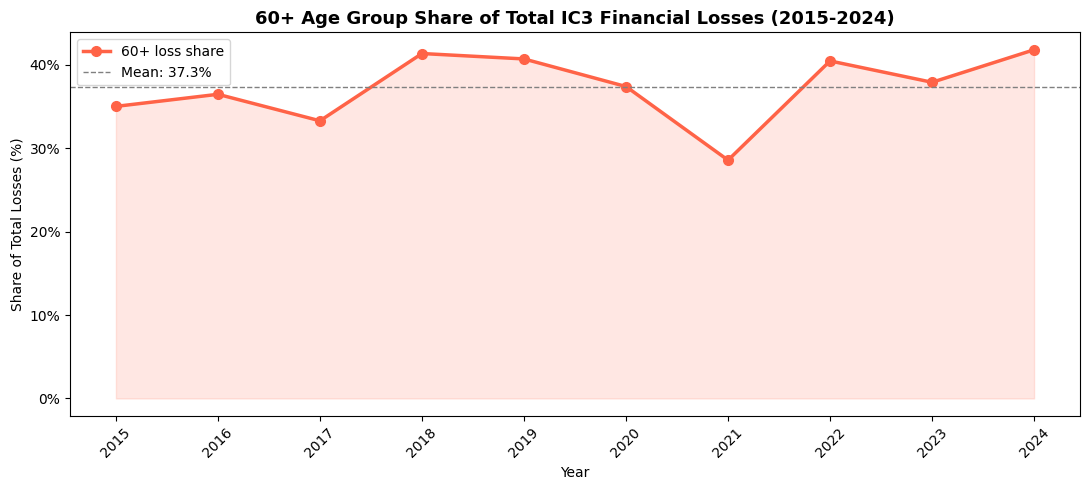

60+ loss share range: 28.58 to 41.82 %


In [6]:
over60 = yearly_age[yearly_age['Age Group'] == '60+'].copy()

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(over60['Year'], over60['Loss Share (%)'],
        marker='o', color='tomato', linewidth=2.5, markersize=7, label='60+ loss share')
ax.fill_between(over60['Year'], over60['Loss Share (%)'],
                alpha=0.15, color='tomato')

ax.axhline(y=over60['Loss Share (%)'].mean(), color='gray',
           linestyle='--', linewidth=1, label=f"Mean: {over60['Loss Share (%)'].mean():.1f}%")

ax.set_title('60+ Age Group Share of Total IC3 Financial Losses (2015-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Share of Total Losses (%)')
ax.set_xticks(over60['Year'])
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('outputs/figures/nb6_over60_loss_share.png', dpi=150, bbox_inches='tight')
plt.show()

print("60+ loss share range:", over60['Loss Share (%)'].min(), "to", over60['Loss Share (%)'].max(), "%")

## 5. Chart - Total Loss by Age Group Over Time

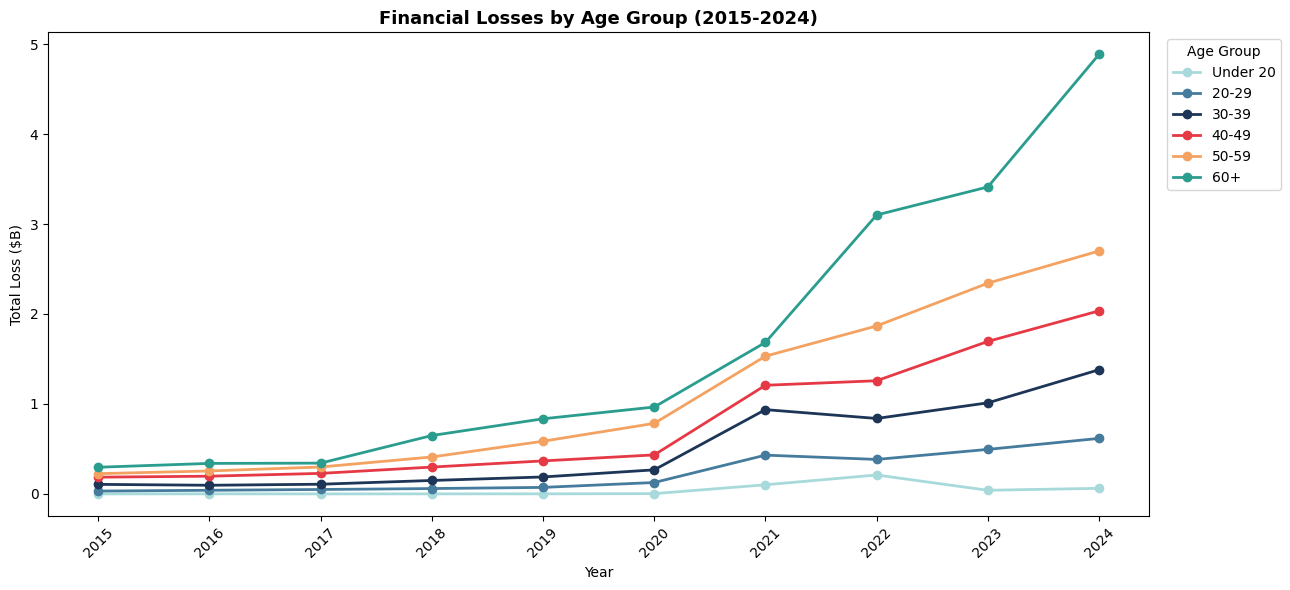

In [7]:
age_order = ['Under 20', '20-29', '30-39', '40-49', '50-59', '60+']
colors    = ['#a8dadc', '#457b9d', '#1d3557', '#e63946', '#f4a261', '#2a9d8f']

fig, ax = plt.subplots(figsize=(13, 6))

for age, color in zip(age_order, colors):
    subset = yearly_age[yearly_age['Age Group'] == age]
    ax.plot(subset['Year'], subset['Loss ($)'] / 1e9,
            marker='o', label=age, color=color, linewidth=2)

ax.set_title('Financial Losses by Age Group (2015-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Total Loss ($B)')
ax.set_xticks(sorted(age_df['Year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('outputs/figures/nb6_losses_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Chart - Complaints by Age Group Over Time

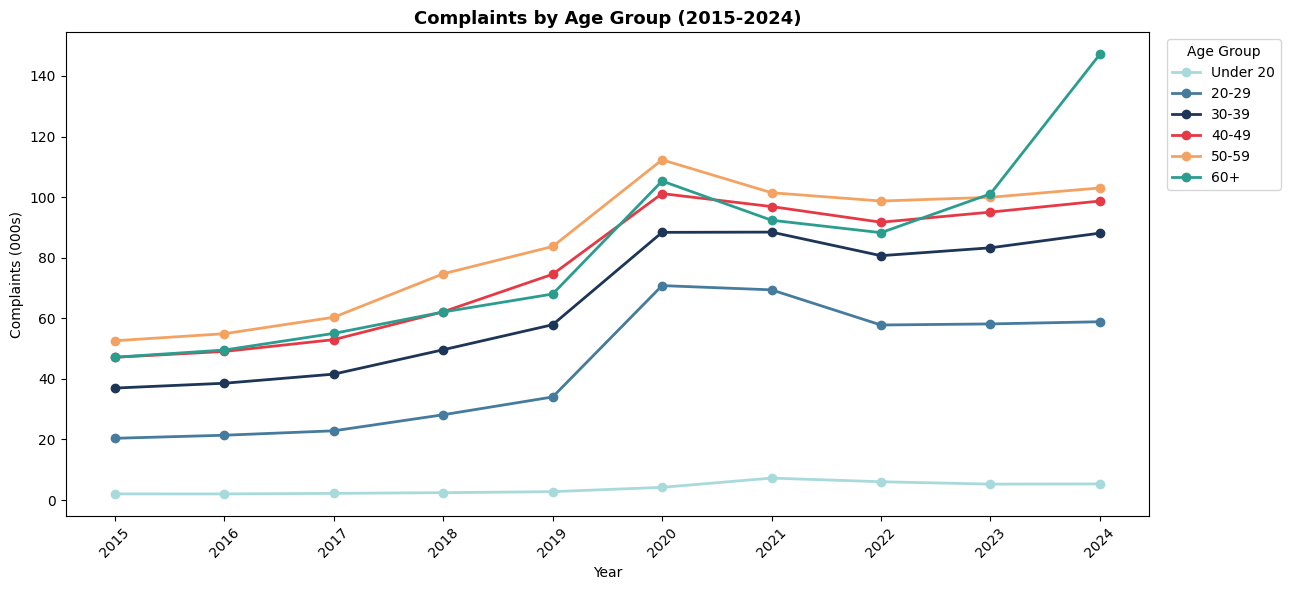

In [8]:
fig, ax = plt.subplots(figsize=(13, 6))

for age, color in zip(age_order, colors):
    subset = yearly_age[yearly_age['Age Group'] == age]
    ax.plot(subset['Year'], subset['Complaints'] / 1e3,
            marker='o', label=age, color=color, linewidth=2)

ax.set_title('Complaints by Age Group (2015-2024)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Complaints (000s)')
ax.set_xticks(sorted(age_df['Year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('outputs/figures/nb6_complaints_by_age_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Chart - Loss per Complaint by Age Group (Severity)

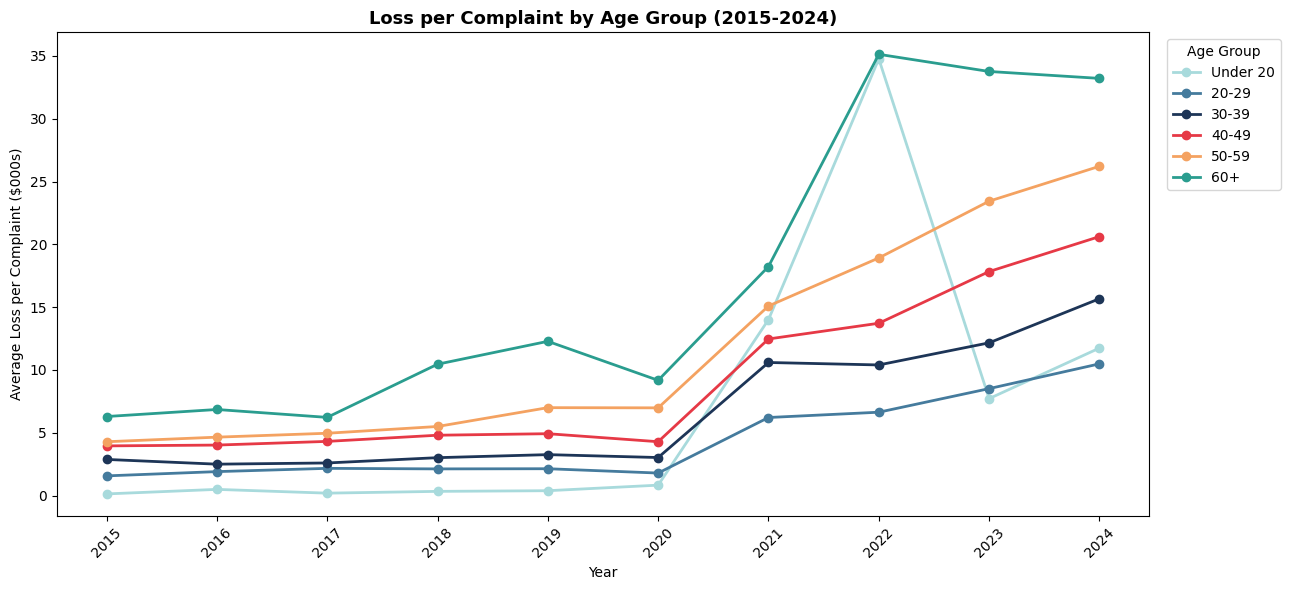

In [9]:
yearly_age['Loss per Complaint'] = (
    yearly_age['Loss ($)'] / yearly_age['Complaints'].replace(0, np.nan)
).round(0)

fig, ax = plt.subplots(figsize=(13, 6))

for age, color in zip(age_order, colors):
    subset = yearly_age[yearly_age['Age Group'] == age]
    ax.plot(subset['Year'], subset['Loss per Complaint'] / 1e3,
            marker='o', label=age, color=color, linewidth=2)

ax.set_title('Loss per Complaint by Age Group (2015-2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Loss per Complaint ($000s)')
ax.set_xticks(sorted(age_df['Year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('outputs/figures/nb6_loss_per_complaint_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("=== 60+ Loss Share by Year ===")
print(over60[['Year', 'Loss Share (%)']].to_string(index=False))

print()
print("=== Loss per Complaint by Age Group 2024 ===")
snapshot = yearly_age[yearly_age['Year'] == 2024][['Age Group', 'Loss per Complaint']].sort_values('Loss per Complaint', ascending=False)
print(snapshot.to_string(index=False))

print()
print("=== Total Loss by Age Group 2024 ===")
snapshot2 = yearly_age[yearly_age['Year'] == 2024][['Age Group', 'Loss ($)']].sort_values('Loss ($)', ascending=False)
print(snapshot2.to_string(index=False))

=== 60+ Loss Share by Year ===
 Year  Loss Share (%)
 2015           35.03
 2016           36.48
 2017           33.30
 2018           41.37
 2019           40.72
 2020           37.41
 2021           28.58
 2022           40.48
 2023           37.92
 2024           41.82

=== Loss per Complaint by Age Group 2024 ===
Age Group  Loss per Complaint
      60+             33209.0
    50-59             26212.0
    40-49             20617.0
    30-39             15670.0
 Under 20             11743.0
    20-29             10487.0

=== Total Loss by Age Group 2024 ===
Age Group   Loss ($)
      60+ 4885983179
    50-59 2700563413
    40-49 2034956284
    30-39 1380637805
    20-29  617308766
 Under 20   62637036


In [11]:
print(1_684_182_136 / 7_647_476_000 * 100)

22.022718815985822
